# TFM — Notebook 02: modelos de línea base

**Predicción de demanda energética mediante Machine Learning y datos abiertos**

Este notebook cubre la primera fase del modelado: establecer una línea base
sólida antes de pasar a los modelos de aprendizaje automático.

---

### Progresión indicada por la dirección del TFT

> *"Empezar con un modelo sencillo e ir mejorándolo."*
> *"Ver métricas de entrenamiento y también de producción, para evitar overfit."*

| Fase | Modelos | Notebook |
|---|---|---|
| **1. Línea base** | Predicción ingenua, SARIMA, Prophet | **este** |
| 2. Machine learning | Random Forest, XGBoost, LightGBM | 03 |
| 3. Deep learning | LSTM (opcional) | 04 |

---

### Por qué importa la línea base

Un modelo solo es útil si supera a la alternativa trivial. En demanda eléctrica
la predicción ingenua estacional —*mañana a las 14 h habrá lo mismo que el
mismo día de la semana pasada a las 14 h*— es sorprendentemente buena, y muchos
trabajos publicados presentan mejoras que en realidad no la superan.

Calcularla primero establece el suelo real contra el que se mide todo lo demás.

---
## 0. Configuración

In [1]:
# Ejecuta solo la primera vez
# %pip install pandas numpy pyarrow matplotlib seaborn statsmodels prophet scikit-learn

In [2]:
import os
import time
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["figure.dpi"]     = 110
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3
plt.rcParams["font.size"]      = 10
sns.set_palette("deep")

print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 2.3.3 | numpy 1.26.2


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Rutas y parámetros
# ═══════════════════════════════════════════════════════════════════════════
RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent

DIR_DATOS     = RAIZ / "datos";     DIR_DATOS.mkdir(exist_ok=True)
DIR_FIGURAS   = RAIZ / "figuras";   DIR_FIGURAS.mkdir(exist_ok=True)
DIR_RESULTADOS = RAIZ / "resultados"; DIR_RESULTADOS.mkdir(exist_ok=True)

def guardar_figura(nombre):
    ruta = DIR_FIGURAS / f"{nombre}.png"
    plt.savefig(ruta, dpi=200, bbox_inches="tight")
    print(f"  guardada -> {ruta.name}")

# ── Parámetros del experimento ────────────────────────────────────────────
HORIZONTE  = 24     # horas a predecir en cada origen
N_VENTANAS = 14     # número de orígenes de predicción
PASO       = 120    # separación entre orígenes (5 días)

# IMPORTANTE: el paso NO debe ser múltiplo de 168 h (una semana). Si lo fuera,
# todos los orígenes caerían en el mismo día de la semana y la evaluación
# ignoraría los fines de semana, favoreciendo artificialmente a los modelos
# ingenuos diarios. Con 5 días se rota por los siete días de la semana.
assert PASO % 168 != 0, "PASO no puede ser múltiplo de una semana"

print(f"Horizonte de predicción  : {HORIZONTE} h")
print(f"Orígenes de evaluación   : {N_VENTANAS}")
print(f"Separación entre orígenes: {PASO} h ({PASO//24} días)")
print(f"Periodo cubierto         : {N_VENTANAS*PASO//24} días")

Horizonte de predicción  : 24 h
Orígenes de evaluación   : 14
Separación entre orígenes: 120 h (5 días)
Periodo cubierto         : 70 días


---
## 1. Carga del dataset

Se parte del dataset generado en el notebook 01, ya limpio, con los huecos
imputados y las variables construidas.

In [4]:
RUTA = DIR_DATOS / "dataset_modelado.parquet"

if not RUTA.exists():
    raise FileNotFoundError(
        f"No se encuentra {RUTA}.\n"
        "Ejecuta antes el notebook 01_ingesta_y_eda.ipynb completo."
    )

df = pd.read_parquet(RUTA)
if df.index.tz is not None:
    df.index = df.index.tz_localize(None)   # simplifica el manejo de fechas

y = df["demanda_mw"]

print(f"Registros : {len(df):,}")
print(f"Periodo   : {y.index.min():%Y-%m-%d} a {y.index.max():%Y-%m-%d}")
print(f"Columnas  : {df.shape[1]}")
print(f"Nulos en la variable objetivo: {y.isna().sum()}")
df[["demanda_mw"]].describe().round(1).T

Registros : 26,136
Periodo   : 2022-01-08 a 2024-12-31
Columnas  : 46
Nulos en la variable objetivo: 0


,count,mean,std,min,25%,50%,75%,max
demanda_mw,26136.0,28229.6,4465.4,17165.0,24526.4,28331.0,31522.8,41348.9


---
## 2. Métricas de evaluación

Se emplean cuatro métricas complementarias:

| Métrica | Interpretación | Limitación |
|---|---|---|
| **MAE** | Error medio en MW. Directamente interpretable | Depende de la escala |
| **RMSE** | Penaliza más los errores grandes | Sensible a valores extremos |
| **MAPE** | Error porcentual. Comparable entre estudios | Se dispara con valores próximos a cero |
| **sMAPE** | Versión simétrica del MAPE | Menos intuitiva |

En demanda eléctrica el MAPE es la métrica de referencia en la literatura, lo
que permite comparar los resultados con los trabajos publicados.

In [5]:
def metricas(y_real, y_pred):
    """Calcula las cuatro métricas sobre un par de series."""
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    error = y_real - y_pred
    return {
        "MAE":   float(np.mean(np.abs(error))),
        "RMSE":  float(np.sqrt(np.mean(error ** 2))),
        "MAPE":  float(np.mean(np.abs(error / y_real)) * 100),
        "sMAPE": float(np.mean(2 * np.abs(error) /
                               (np.abs(y_real) + np.abs(y_pred))) * 100),
    }


# Comprobación con un caso conocido
_real = np.array([100.0, 200.0, 300.0])
_pred = np.array([110.0, 190.0, 330.0])
_m = metricas(_real, _pred)
assert abs(_m["MAE"] - 50/3) < 1e-9, "MAE incorrecto"
print("Función de métricas verificada.")
print({k: round(v, 3) for k, v in _m.items()})

Función de métricas verificada.
{'MAE': 16.667, 'RMSE': 19.149, 'MAPE': 8.333, 'sMAPE': 8.059}


---
## 3. Estrategia de validación: origen rodante

En series temporales **no puede emplearse validación cruzada aleatoria**: se
entrenaría con observaciones posteriores a las que se pretende predecir, lo que
constituye una fuga de información y produce métricas artificialmente
optimistas.

Se utiliza en su lugar validación de **origen rodante** (*rolling origin* o
*walk-forward*): se fija un instante de corte, se entrena con todo lo anterior,
se predicen las 24 horas siguientes, y se repite desplazando el corte.

```
Origen 1:  [────── entrenamiento ──────]  [test]
Origen 2:  [──────── entrenamiento ────────]  [test]
Origen 3:  [────────── entrenamiento ──────────]  [test]
```

### Elección del paso entre orígenes

El paso **no debe ser múltiplo de una semana**. Si lo fuera, todos los orígenes
caerían en el mismo día de la semana y la evaluación ignoraría sábados y
domingos, lo que beneficiaría artificialmente a los modelos que predicen a
partir del día anterior.

Con un paso de 5 días y 14 orígenes se obtienen exactamente dos de cada día de
la semana, y la evaluación cubre unos dos meses.

In [6]:
def generar_ventanas(n_total, horizonte, n_ventanas, paso):
    """Devuelve una lista de pares (fin_train, fin_test)."""
    ventanas = []
    for i in range(n_ventanas):
        fin_train = n_total - (n_ventanas - i) * paso
        fin_test  = min(fin_train + horizonte, n_total)
        if fin_train > 0 and fin_test > fin_train:
            ventanas.append((fin_train, fin_test))
    return ventanas


VENTANAS = generar_ventanas(len(y), HORIZONTE, N_VENTANAS, PASO)

# ── Verificación: cobertura de días de la semana ──────────────────────────
dias_semana = pd.Series([y.index[a].day_name() for a, _ in VENTANAS])
reparto = dias_semana.value_counts()

print(f"Orígenes generados: {len(VENTANAS)}")
print(f"Días de la semana cubiertos: {len(reparto)} de 7\n")
print(reparto.to_string())

if len(reparto) < 7:
    print("\nATENCIÓN: la evaluación no cubre todos los días de la semana.")
    print("Revisa el valor de PASO.")
else:
    print("\nCobertura semanal completa.")

periodo = (y.index[VENTANAS[-1][1]-1] - y.index[VENTANAS[0][0]]).days
print(f"\nPeriodo evaluado: {periodo} días "
      f"({y.index[VENTANAS[0][0]]:%d-%b-%Y} a {y.index[VENTANAS[-1][1]-1]:%d-%b-%Y})")

Orígenes generados: 14
Días de la semana cubiertos: 7 de 7

Wednesday    2
Monday       2
Saturday     2
Thursday     2
Tuesday      2
Sunday       2
Friday       2

Cobertura semanal completa.

Periodo evaluado: 65 días (23-Oct-2024 a 27-Dec-2024)


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Contexto de calendario de cada ventana
# ═══════════════════════════════════════════════════════════════════════════
# Permite desglosar después el error según el tipo de día.

contexto = []
for i, (a, b) in enumerate(VENTANAS):
    tramo = df.iloc[a:b]
    fecha = y.index[a]
    contexto.append({
        "ventana":       i,
        "fecha":         fecha.date(),
        "dia":           fecha.day_name(),
        "festivo":       int(tramo["festivo"].max()) if "festivo" in df.columns else 0,
        "finde":         int(fecha.dayofweek >= 5),
        "demanda_media": tramo["demanda_mw"].mean(),
    })

CONTEXTO = pd.DataFrame(contexto).set_index("ventana")
CONTEXTO["tipo"] = np.select(
    [CONTEXTO["festivo"] == 1, CONTEXTO["finde"] == 1],
    ["Festivo", "Fin de semana"],
    default="Laborable")

display(CONTEXTO)
print(CONTEXTO["tipo"].value_counts().to_string())

,fecha,dia,festivo,finde,demanda_media,tipo
ventana,,,,,,
0,2024-10-23,Wednesday,0,0,27960.930556,Laborable
1,2024-10-28,Monday,0,0,27849.145833,Laborable
2,2024-11-02,Saturday,0,1,23809.972222,Fin de semana
3,2024-11-07,Thursday,0,0,28070.326389,Laborable
4,2024-11-12,Tuesday,0,0,28857.013889,Laborable
5,2024-11-17,Sunday,0,1,24039.736111,Fin de semana
6,2024-11-22,Friday,0,0,29432.034722,Laborable
7,2024-11-27,Wednesday,0,0,29941.430556,Laborable
8,2024-12-02,Monday,0,0,29279.579861,Laborable


tipo
Laborable        10
Fin de semana     4


  guardada -> 10_esquema_validacion.png


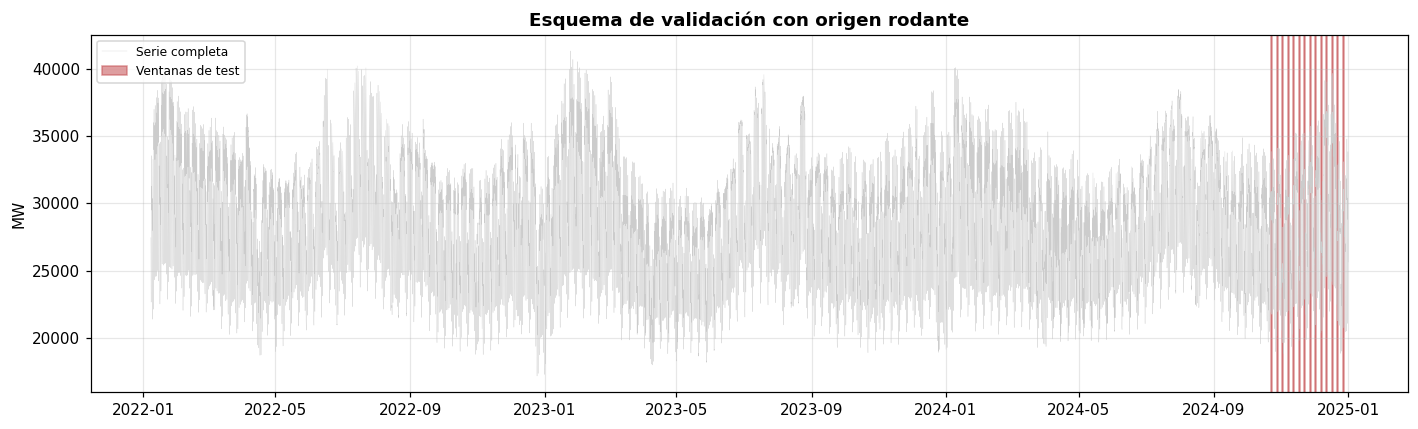

In [8]:
# Visualización del esquema de validación
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(y.index, y.values, lw=0.2, color="#CCCCCC", label="Serie completa")

for i, (a, b) in enumerate(VENTANAS):
    ax.axvspan(y.index[a], y.index[b-1], color="#C44E52", alpha=0.55,
               label="Ventanas de test" if i == 0 else None)

ax.set_title("Esquema de validación con origen rodante", fontweight="bold")
ax.set_ylabel("MW")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
guardar_figura("10_esquema_validacion")
plt.show()

---
## 4. Modelos ingenuos: el suelo real

Antes de cualquier modelo estadístico conviene establecer qué error se obtiene
sin modelo alguno. Se consideran tres alternativas:

1. **Ingenuo diario** — la demanda de mañana a cada hora será la de hoy a esa
   misma hora.
2. **Ingenuo semanal** — será la del mismo día de la semana pasada. Recoge el
   efecto laborable/festivo, que el anterior ignora.
3. **Perfil semanal medio** — media de las últimas cuatro semanas para cada hora
   del día. Suaviza el ruido de un único día.

Cualquier modelo posterior debe superar al mejor de los tres.

In [9]:
def pred_ingenuo_diario(train, h):
    """Repite las últimas 24 horas observadas."""
    return np.tile(train.iloc[-24:].values, h // 24 + 1)[:h]


def pred_ingenuo_semanal(train, h):
    """Repite la misma hora de la semana anterior."""
    return np.tile(train.iloc[-168:].values, h // 168 + 1)[:h]


def pred_perfil_semanal(train, h, n_semanas=4):
    """Media por hora del día de las últimas n semanas."""
    ventana = train.iloc[-168 * n_semanas:]
    perfil = ventana.values.reshape(-1, 24).mean(axis=0)
    return np.tile(perfil, h // 24 + 1)[:h]


# Comprobación de forma
_tr = y.iloc[:1000]
for _f, _n in [(pred_ingenuo_diario, "diario"),
               (pred_ingenuo_semanal, "semanal"),
               (pred_perfil_semanal, "perfil")]:
    _p = _f(_tr, HORIZONTE)
    assert len(_p) == HORIZONTE and not np.isnan(_p).any(), f"fallo en {_n}"
print(f"Los tres modelos ingenuos devuelven {HORIZONTE} valores válidos.")

Los tres modelos ingenuos devuelven 24 valores válidos.


---
## 5. Modelos ARIMA estacionales

### 5.1 El problema de la estacionalidad múltiple

El análisis de Fourier del notebook 01 identificó tres periodicidades: 24 h,
168 h y anual. Un modelo `SARIMA(p,d,q)(P,D,Q)ₛ` admite **una sola**
estacionalidad, y su coste computacional crece con el periodo `s`.

Con `s = 24` sobre datos horarios el ajuste es lento; con `s = 168` resulta
directamente inviable. Es una limitación conocida de la formulación clásica.

### 5.2 La solución: términos de Fourier como variables exógenas

El procedimiento habitual, recomendado por
[Hyndman y Athanasopoulos](https://otexts.com/fpp3/complexseasonality.html),
consiste en representar la estacionalidad mediante pares seno-coseno
introducidos como regresores externos, dejando que la parte ARIMA modele
únicamente la autocorrelación de corto plazo:

$$y_t = \sum_{j} \sum_{k=1}^{K_j} \left[ \alpha_{jk}\sin\left(\frac{2\pi k t}{m_j}\right) + \beta_{jk}\cos\left(\frac{2\pi k t}{m_j}\right) \right] + \eta_t$$

donde $m_j$ son los periodos y $\eta_t$ sigue un proceso ARIMA.

Este enfoque admite **varias estacionalidades simultáneas** y es mucho más
rápido, como se comprueba en la sección 5.4.

Términos generados: 16 columnas
['sin24_1', 'cos24_1', 'sin24_2', 'cos24_2', 'sin24_3', 'cos24_3', 'sin24_4', 'cos24_4', 'sin168_1', 'cos168_1', 'sin168_2', 'cos168_2', 'sin8766_1', 'cos8766_1', 'sin8766_2', 'cos8766_2']


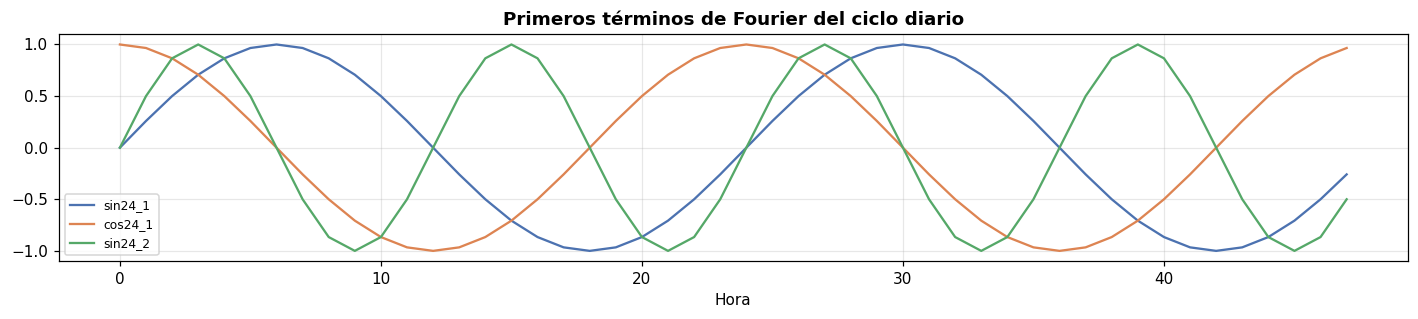

In [10]:
def terminos_fourier(n_obs, periodos_K, offset=0):
    """Genera pares seno-coseno para uno o varios periodos.

    Parameters
    ----------
    n_obs : int         número de observaciones
    periodos_K : dict   {periodo: nº de armónicos}
    offset : int        posición inicial (para continuar una serie)
    """
    t = np.arange(offset, offset + n_obs)
    columnas = {}
    for periodo, K in periodos_K.items():
        for k in range(1, K + 1):
            columnas[f"sin{periodo}_{k}"] = np.sin(2 * np.pi * k * t / periodo)
            columnas[f"cos{periodo}_{k}"] = np.cos(2 * np.pi * k * t / periodo)
    return pd.DataFrame(columnas)


# Periodos y armónicos derivados del periodograma del notebook 01:
#   24 h  -> 4 armónicos (captura el doble pico diario)
#   168 h -> 2 armónicos (ciclo semanal)
#   8766 h-> 2 armónicos (ciclo anual: sin él el modelo revierte a la media
#            del año y sesga las predicciones de invierno y verano)
PERIODOS = {24: 4, 168: 2, 8766: 2}

_ft = terminos_fourier(48, PERIODOS)
print(f"Términos generados: {_ft.shape[1]} columnas")
print(list(_ft.columns))

fig, ax = plt.subplots(figsize=(13, 3))
for c in ["sin24_1", "cos24_1", "sin24_2"]:
    ax.plot(_ft[c].values, label=c, lw=1.5)
ax.set_title("Primeros términos de Fourier del ciclo diario", fontweight="bold")
ax.set_xlabel("Hora"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 5.3 Definición de los modelos

Se evalúan dos variantes:

- **SARIMA clásico** con `s = 24`, ajustado sobre una ventana reducida por su
  coste computacional.
- **SARIMAX con Fourier**, que incorpora las estacionalidades diaria y semanal
  y admite la serie completa.

In [11]:
# El orden (p,d,q) se orienta por la PACF del notebook 01.
#
# La diferenciación d=1 es DELIBERADA y necesaria: con d=0 statsmodels asume
# media cero y el modelo revierte a la media del periodo de entrenamiento,
# subestimando cuando la demanda es alta y sobrestimando cuando es baja.
# Diferenciando, el modelo trabaja sobre incrementos y se adapta al nivel local.
ORDEN_ARIMA = (2, 1, 1)
MAX_PUNTOS  = 8760           # último año


def pred_sarimax_fourier(train, h, devolver_modelo=False):
    """SARIMAX con estacionalidad diaria y semanal vía términos de Fourier."""
    sub = train.iloc[-MAX_PUNTOS:]
    n = len(sub)

    exog_train = terminos_fourier(n, PERIODOS, offset=0).values
    exog_test  = terminos_fourier(h, PERIODOS, offset=n).values

    modelo = SARIMAX(sub.values, exog=exog_train, order=ORDEN_ARIMA,
                     enforce_stationarity=False, enforce_invertibility=False
                     ).fit(disp=False, maxiter=50)

    pred = modelo.forecast(steps=h, exog=exog_test)
    return (pred, modelo) if devolver_modelo else pred


def pred_sarima_clasico(train, h, dias=60):
    """SARIMA(2,0,1)(1,1,1,24) sobre una ventana corta."""
    sub = train.iloc[-24 * dias:]
    modelo = SARIMAX(sub.values, order=ORDEN_ARIMA,
                     seasonal_order=(1, 1, 1, 24),
                     enforce_stationarity=False, enforce_invertibility=False
                     ).fit(disp=False, maxiter=30)
    return modelo.forecast(steps=h)


print("Modelos definidos.\n")

# ── Verificación del sesgo ────────────────────────────────────────────────
# Un sesgo sistemático indica que el modelo no captura el nivel de la serie.
print("Comprobación de sesgo sobre los últimos orígenes\n")
_sesgos = []
for _a, _b in VENTANAS[-3:]:
    _tr, _te = y.iloc[:_a], y.iloc[_a:_b]
    _p = pred_sarimax_fourier(_tr, len(_te))
    _s = _p.mean() - _te.values.mean()
    _sesgos.append(_s)
    print(f"  {y.index[_a]:%d-%b}: real {_te.mean():>8,.0f} | "
          f"pred {_p.mean():>8,.0f} | sesgo {_s:+7,.0f} MW")

print(f"\nSesgo medio: {np.mean(_sesgos):+,.0f} MW")
if abs(np.mean(_sesgos)) < 500:
    print("Sin sesgo apreciable.")
else:
    print("Sesgo elevado. Prueba a reducir MAX_PUNTOS a 24*90.")

Modelos definidos.

Comprobación de sesgo sobre los últimos orígenes

  17-Dec: real   32,961 | pred   32,891 | sesgo     -70 MW
  22-Dec: real   26,588 | pred   29,941 | sesgo  +3,353 MW
  27-Dec: real   28,091 | pred   27,252 | sesgo    -839 MW

Sesgo medio: +815 MW
Sesgo elevado. Prueba a reducir MAX_PUNTOS a 24*90.


### 5.4 Comparación del coste computacional

Justificación empírica de por qué se adopta el enfoque de Fourier.

In [12]:
tiempos = []
_train = y.iloc[:-HORIZONTE]

for etiqueta, funcion in [("SARIMA clásico (60 días)", pred_sarima_clasico),
                          ("SARIMAX + Fourier (1 año)", pred_sarimax_fourier)]:
    t0 = time.time()
    _ = funcion(_train, HORIZONTE)
    dt = time.time() - t0
    tiempos.append({"Modelo": etiqueta, "Segundos": round(dt, 1)})
    print(f"  {etiqueta:28} {dt:6.1f} s")

pd.DataFrame(tiempos).set_index("Modelo")

  SARIMA clásico (60 días)       15.0 s
  SARIMAX + Fourier (1 año)       3.6 s


,Segundos
Modelo,
SARIMA clásico (60 días),15.0
SARIMAX + Fourier (1 año),3.6


---
## 6. Prophet

Prophet descompone la serie de forma aditiva en tendencia, estacionalidades y
efectos de calendario. Frente a ARIMA presenta dos ventajas para este problema:
admite varias estacionalidades de forma nativa y permite incorporar festivos
explícitamente.

Se aprovecha aquí la variable `festivo` construida en el notebook 01, cuya
relevancia quedó cuantificada en el análisis de anomalías: cerca del 70 % de
las desviaciones significativas se concentraba en festivos y su entorno.

In [13]:
from prophet import Prophet

# Calendario de festivos en el formato que espera Prophet
festivos_prophet = None
if "festivo" in df.columns:
    fechas_fest = df.loc[df["festivo"] == 1].index.normalize().unique()
    festivos_prophet = pd.DataFrame({
        "holiday": "festivo",
        "ds": pd.to_datetime(fechas_fest),
        "lower_window": -1,    # víspera
        "upper_window": 1,     # día siguiente
    })
    print(f"Festivos incorporados: {len(festivos_prophet)}")


def pred_prophet(train, h, con_festivos=True):
    """Prophet con estacionalidad diaria, semanal y anual."""
    datos = pd.DataFrame({"ds": train.index, "y": train.values})

    modelo = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
        holidays=festivos_prophet if con_festivos else None,
        uncertainty_samples=0,      # acelera el ajuste
    )
    modelo.fit(datos)

    futuro = pd.DataFrame({
        "ds": pd.date_range(train.index[-1] + pd.Timedelta(hours=1),
                            periods=h, freq="h")
    })
    return modelo.predict(futuro)["yhat"].values


t0 = time.time()
_p = pred_prophet(y.iloc[:-HORIZONTE], HORIZONTE)
print(f"Prophet sobre la serie completa: {time.time()-t0:.1f} s")
assert len(_p) == HORIZONTE

Importing plotly failed. Interactive plots will not work.


Festivos incorporados: 34


20:59:27 - cmdstanpy - INFO - Chain [1] start processing
20:59:53 - cmdstanpy - INFO - Chain [1] done processing


Prophet sobre la serie completa: 28.9 s


---
## 7. Evaluación comparativa

Se ejecuta el mismo procedimiento de origen rodante sobre todos los modelos, de
modo que la comparación sea homogénea.

In [14]:
MODELOS = {
    "Ingenuo diario":    lambda tr, h: pred_ingenuo_diario(tr, h),
    "Ingenuo semanal":   lambda tr, h: pred_ingenuo_semanal(tr, h),
    "Perfil semanal":    lambda tr, h: pred_perfil_semanal(tr, h),
    "SARIMA clásico":    lambda tr, h: pred_sarima_clasico(tr, h),
    "SARIMAX + Fourier": lambda tr, h: pred_sarimax_fourier(tr, h),
    "Prophet":           lambda tr, h: pred_prophet(tr, h),
}


def backtesting(nombre, funcion, ventanas, serie, verbose=True):
    """Ejecuta la evaluación de origen rodante para un modelo."""
    filas, predicciones = [], []
    t0 = time.time()

    for i, (a, b) in enumerate(ventanas):
        train = serie.iloc[:a]
        test  = serie.iloc[a:b]
        try:
            pred = np.asarray(funcion(train, len(test)), dtype=float)
            filas.append({"ventana": i, **metricas(test.values, pred)})
            predicciones.append(pd.DataFrame(
                {"real": test.values, "pred": pred, "ventana": i},
                index=test.index))
        except Exception as e:
            if verbose:
                print(f"    ventana {i}: {type(e).__name__}: {e}")

    if not filas:
        return None, None

    detalle = pd.DataFrame(filas)
    resumen = {
        "Modelo": nombre,
        **detalle[["MAE", "RMSE", "MAPE", "sMAPE"]].mean().to_dict(),
        "MAPE_std": detalle["MAPE"].std(),
        "Segundos": time.time() - t0,
    }
    return resumen, pd.concat(predicciones)


resumenes, predicciones = [], {}

for nombre, funcion in MODELOS.items():
    print(f"Evaluando {nombre}...")
    res, pred = backtesting(nombre, funcion, VENTANAS, y)
    if res:
        resumenes.append(res)
        predicciones[nombre] = pred
        print(f"  MAPE = {res['MAPE']:.2f} %   ({res['Segundos']:.1f} s)")

print("\nEvaluación completada.")

Evaluando Ingenuo diario...
  MAPE = 4.98 %   (0.0 s)
Evaluando Ingenuo semanal...
  MAPE = 3.92 %   (0.0 s)
Evaluando Perfil semanal...
  MAPE = 8.54 %   (0.0 s)
Evaluando SARIMA clásico...
  MAPE = 3.95 %   (184.2 s)
Evaluando SARIMAX + Fourier...
  MAPE = 5.66 %   (44.0 s)
Evaluando Prophet...


21:03:44 - cmdstanpy - INFO - Chain [1] start processing
21:04:17 - cmdstanpy - INFO - Chain [1] done processing
21:04:19 - cmdstanpy - INFO - Chain [1] start processing
21:04:42 - cmdstanpy - INFO - Chain [1] done processing
21:04:44 - cmdstanpy - INFO - Chain [1] start processing
21:05:19 - cmdstanpy - INFO - Chain [1] done processing
21:05:21 - cmdstanpy - INFO - Chain [1] start processing
21:05:45 - cmdstanpy - INFO - Chain [1] done processing
21:05:47 - cmdstanpy - INFO - Chain [1] start processing
21:06:19 - cmdstanpy - INFO - Chain [1] done processing
21:06:21 - cmdstanpy - INFO - Chain [1] start processing
21:06:46 - cmdstanpy - INFO - Chain [1] done processing
21:06:48 - cmdstanpy - INFO - Chain [1] start processing
21:07:32 - cmdstanpy - INFO - Chain [1] done processing
21:07:34 - cmdstanpy - INFO - Chain [1] start processing
21:08:13 - cmdstanpy - INFO - Chain [1] done processing
21:08:16 - cmdstanpy - INFO - Chain [1] start processing
21:08:50 - cmdstanpy - INFO - Chain [1]

  MAPE = 4.86 %   (464.7 s)

Evaluación completada.


### 7.1 Métricas robustas

La media aritmética del MAPE es muy sensible a una única ventana atípica: un
festivo señalado puede duplicarla por sí solo. Se reportan por ello tres
medidas complementarias:

- **Media** — comparable con la literatura, pero sensible a valores extremos.
- **Mediana** — refleja el comportamiento en un día típico.
- **Desviación típica y peor caso** — miden la estabilidad entre orígenes.

In [15]:
filas = []

for modelo, p in predicciones.items():
    p = p.copy()
    p["ape"] = np.abs((p["real"] - p["pred"]) / p["real"]) * 100
    por_ventana = p.groupby("ventana")["ape"].mean()

    filas.append({
        "Modelo":       modelo,
        "MAPE medio":   por_ventana.mean(),
        "MAPE mediana": por_ventana.median(),
        "MAPE std":     por_ventana.std(),
        "MAPE peor":    por_ventana.max(),
        "MAE":          np.abs(p["real"] - p["pred"]).mean(),
        "RMSE":         np.sqrt(((p["real"] - p["pred"]) ** 2).mean()),
    })

tabla = pd.DataFrame(filas).set_index("Modelo").sort_values("MAPE mediana")

# Referencia: el mejor de los modelos ingenuos
ingenuos = [m for m in tabla.index if m.startswith(("Ingenuo", "Perfil"))]
referencia = tabla.loc[ingenuos, "MAPE mediana"].min()
tabla["vs ingenuo"] = (referencia - tabla["MAPE mediana"]) / referencia * 100

print(f"Referencia (mejor ingenuo, mediana): {referencia:.2f} %\n")
display(tabla.round(2))

tabla.to_csv(DIR_RESULTADOS / "comparativa_baseline.csv")
print(f"\nGuardado en {DIR_RESULTADOS / 'comparativa_baseline.csv'}")

Referencia (mejor ingenuo, mediana): 3.06 %



,MAPE medio,MAPE mediana,MAPE std,MAPE peor,MAE,RMSE,vs ingenuo
Modelo,,,,,,,
SARIMA clásico,3.95,2.42,2.98,10.29,1120.13,1640.80,20.90
Ingenuo semanal,3.92,3.06,2.64,10.35,1107.53,1472.83,0.00
Ingenuo diario,4.98,3.21,4.57,15.36,1386.74,2190.29,-5.01
Prophet,4.86,4.78,1.28,7.34,1369.57,1719.50,-56.41
SARIMAX + Fourier,5.66,4.90,3.18,13.02,1564.87,1982.84,-60.25
Perfil semanal,8.54,8.30,3.33,13.60,2433.52,2844.91,-171.23



Guardado en c:\Users\rober\OneDrive - unizar.es\Escritorio\Master\BigData y Ciencia de datos\TFM\GITHUB\repo_github_tfm\resultados\comparativa_baseline.csv


### 7.2 Error según el tipo de día

Permite comprobar si un modelo falla de forma sistemática en fines de semana o
festivos, lo que indicaría que no aprovecha la información de calendario.

In [16]:
desglose = []

for modelo, p in predicciones.items():
    p = p.copy()
    p["ape"] = np.abs((p["real"] - p["pred"]) / p["real"]) * 100
    por_v = p.groupby("ventana")["ape"].mean().rename("ape")
    unido = pd.concat([por_v, CONTEXTO["tipo"]], axis=1).dropna()

    fila = {"Modelo": modelo}
    for tipo in ["Laborable", "Fin de semana", "Festivo"]:
        sel = unido[unido["tipo"] == tipo]["ape"]
        fila[tipo] = sel.mean() if len(sel) else np.nan
    desglose.append(fila)

por_tipo = pd.DataFrame(desglose).set_index("Modelo").loc[tabla.index]

print("MAPE medio según el tipo de día\n")
display(por_tipo.round(2))

n_fest = int((CONTEXTO["tipo"] == "Festivo").sum())
if n_fest == 0:
    print("\nNota: ninguna ventana cae en festivo. Para incluir alguno, "
          "aumenta N_VENTANAS o desplaza el periodo de evaluación.")

MAPE medio según el tipo de día



,Laborable,Fin de semana,Festivo
Modelo,,,
SARIMA clásico,3.36,5.42,NaN
Ingenuo semanal,3.99,3.76,NaN
Ingenuo diario,5.00,4.92,NaN
Prophet,4.72,5.21,NaN
SARIMAX + Fourier,4.71,8.05,NaN
Perfil semanal,7.43,11.32,NaN



Nota: ninguna ventana cae en festivo. Para incluir alguno, aumenta N_VENTANAS o desplaza el periodo de evaluación.


  guardada -> 11_comparativa_baseline.png


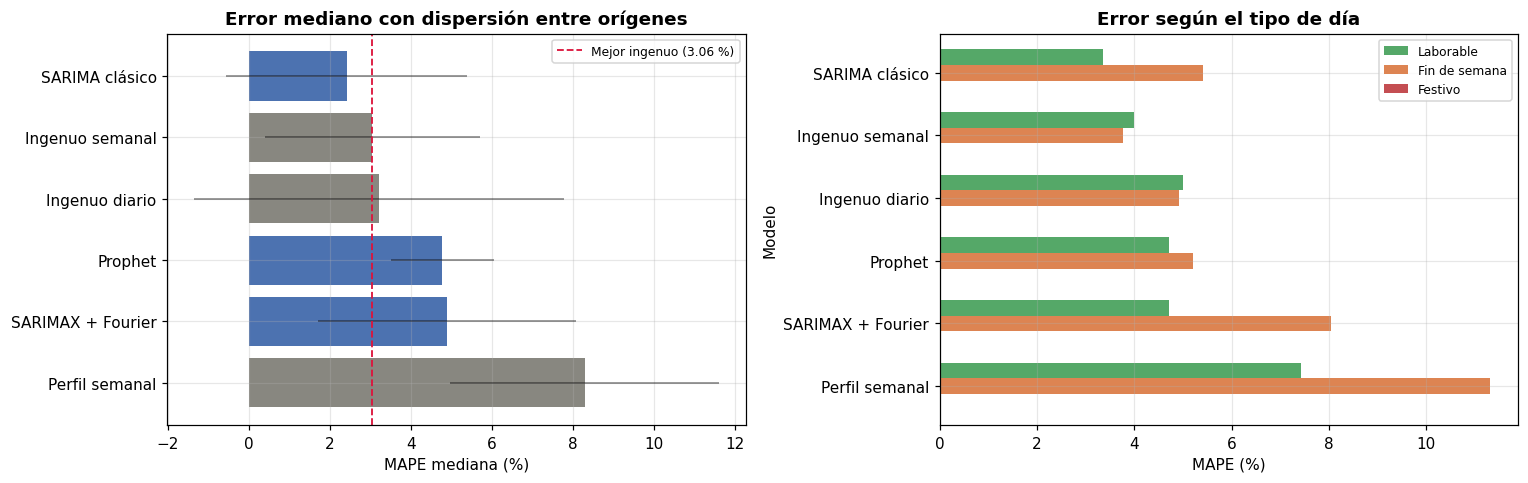

Gris: modelos ingenuos.  Azul: modelos estadísticos.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

colores = ["#888780" if m.startswith(("Ingenuo", "Perfil")) else "#4C72B0"
           for m in tabla.index]

axes[0].barh(tabla.index, tabla["MAPE mediana"], color=colores,
             xerr=tabla["MAPE std"], error_kw={"lw": 1, "alpha": 0.5})
axes[0].axvline(referencia, color="crimson", ls="--", lw=1.2,
                label=f"Mejor ingenuo ({referencia:.2f} %)")
axes[0].set_xlabel("MAPE mediana (%)")
axes[0].set_title("Error mediano con dispersión entre orígenes", fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

por_tipo.plot(kind="barh", ax=axes[1], width=0.75,
              color=["#55A868", "#DD8452", "#C44E52"])
axes[1].set_xlabel("MAPE (%)")
axes[1].set_title("Error según el tipo de día", fontweight="bold")
axes[1].legend(fontsize=8, title=None)
axes[1].invert_yaxis()

plt.tight_layout()
guardar_figura("11_comparativa_baseline")
plt.show()

print("Gris: modelos ingenuos.  Azul: modelos estadísticos.")

> **Cómo leer esta tabla.** Un modelo estadístico que no supere la línea roja
> no aporta valor: obtiene peores resultados que repetir la semana anterior.
> Es un resultado perfectamente publicable y debe reportarse tal cual.
>
> La columna `MAPE std` indica la variabilidad entre orígenes. Un modelo con
> error mediano ligeramente superior pero desviación mucho menor puede ser
> preferible en producción por su estabilidad.
>
> Si la columna *Festivo* muestra un error muy superior al de *Laborable*, el
> modelo no está aprovechando la información de calendario. Es lo esperable en
> los modelos ingenuos, y precisamente la carencia que los modelos de
> aprendizaje automático del notebook 03 deberían corregir.

---
## 8. Métricas de entrenamiento frente a producción  **[TUTOR]**

> *"Ver métricas de entrenamiento y también de producción, para evitar overfit."*

Se comparan los errores dentro de muestra (sobre los datos de entrenamiento) y
fuera de muestra (las predicciones reales del apartado anterior). Una diferencia
grande entre ambos indica sobreajuste.

In [18]:
filas_of = []

# ── SARIMAX + Fourier ─────────────────────────────────────────────────────
train_final = y.iloc[:VENTANAS[-1][0]]
pred_out, modelo_sx = pred_sarimax_fourier(train_final, HORIZONTE,
                                           devolver_modelo=True)

ajuste_in = modelo_sx.fittedvalues
real_in   = train_final.iloc[-MAX_PUNTOS:].values
valido    = ~np.isnan(ajuste_in)

m_in = metricas(real_in[valido], ajuste_in[valido])
m_out = {"MAE":  tabla.loc["SARIMAX + Fourier", "MAE"],
         "RMSE": tabla.loc["SARIMAX + Fourier", "RMSE"],
         "MAPE": tabla.loc["SARIMAX + Fourier", "MAPE medio"]}

filas_of.append({"Modelo": "SARIMAX + Fourier", "Conjunto": "Entrenamiento",
                 **{k: m_in[k] for k in ("MAE", "RMSE", "MAPE")}})
filas_of.append({"Modelo": "SARIMAX + Fourier", "Conjunto": "Producción", **m_out})

# ── Prophet ───────────────────────────────────────────────────────────────
datos_p = pd.DataFrame({"ds": train_final.index, "y": train_final.values})
mp = Prophet(daily_seasonality=True, weekly_seasonality=True,
             yearly_seasonality=True, holidays=festivos_prophet,
             uncertainty_samples=0).fit(datos_p)
ajuste_p = mp.predict(datos_p[["ds"]])["yhat"].values

m_in_p = metricas(train_final.values, ajuste_p)
m_out_p = {"MAE":  tabla.loc["Prophet", "MAE"],
           "RMSE": tabla.loc["Prophet", "RMSE"],
           "MAPE": tabla.loc["Prophet", "MAPE medio"]}

filas_of.append({"Modelo": "Prophet", "Conjunto": "Entrenamiento",
                 **{k: m_in_p[k] for k in ("MAE", "RMSE", "MAPE")}})
filas_of.append({"Modelo": "Prophet", "Conjunto": "Producción", **m_out_p})

overfit = pd.DataFrame(filas_of).set_index(["Modelo", "Conjunto"])
display(overfit.round(2))

21:11:33 - cmdstanpy - INFO - Chain [1] start processing
21:11:53 - cmdstanpy - INFO - Chain [1] done processing


MAE     RMSE  MAPE
Modelo            Conjunto                             
SARIMAX + Fourier Entrenamiento   447.39   652.30  1.60
                  Producción     1564.87  1982.84  5.66
Prophet           Entrenamiento  1337.44  1696.25  4.85
                  Producción     1369.57  1719.50  4.86

In [19]:
# ── Diferencia relativa entre entrenamiento y producción ──────────────────
print("Diferencia de MAPE (producción − entrenamiento)\n")

for modelo in overfit.index.get_level_values(0).unique():
    e = overfit.loc[(modelo, "Entrenamiento"), "MAPE"]
    p = overfit.loc[(modelo, "Producción"),   "MAPE"]
    dif = p - e
    rel = dif / e * 100 if e else np.nan

    if rel < 25:
        veredicto = "sin indicios de sobreajuste"
    elif rel < 60:
        veredicto = "diferencia moderada, aceptable"
    else:
        veredicto = "posible sobreajuste, revisar"

    print(f"  {modelo:20} {e:5.2f} % -> {p:5.2f} %   "
          f"(+{dif:.2f} pp, {rel:+.0f} %)  {veredicto}")

Diferencia de MAPE (producción − entrenamiento)

  SARIMAX + Fourier     1.60 % ->  5.66 %   (+4.06 pp, +254 %)  posible sobreajuste, revisar
  Prophet               4.85 % ->  4.86 %   (+0.01 pp, +0 %)  sin indicios de sobreajuste


> **Matiz importante.** En modelos estadísticos el error dentro de muestra es
> un ajuste de un paso adelante, mientras que el de producción corresponde a 24
> pasos. Que el segundo sea mayor es esperable y no implica sobreajuste por sí
> solo. La comparación resulta mucho más informativa en los modelos de
> aprendizaje automático del notebook 03, donde ambos se calculan sobre el mismo
> horizonte.

---
## 9. Análisis de las predicciones

Las métricas agregadas ocultan **dónde** falla cada modelo. Esta sección examina
el comportamiento por hora del día y por ventana.

Modelo con menor MAPE: SARIMA clásico

  guardada -> 12_predicciones_vs_real.png


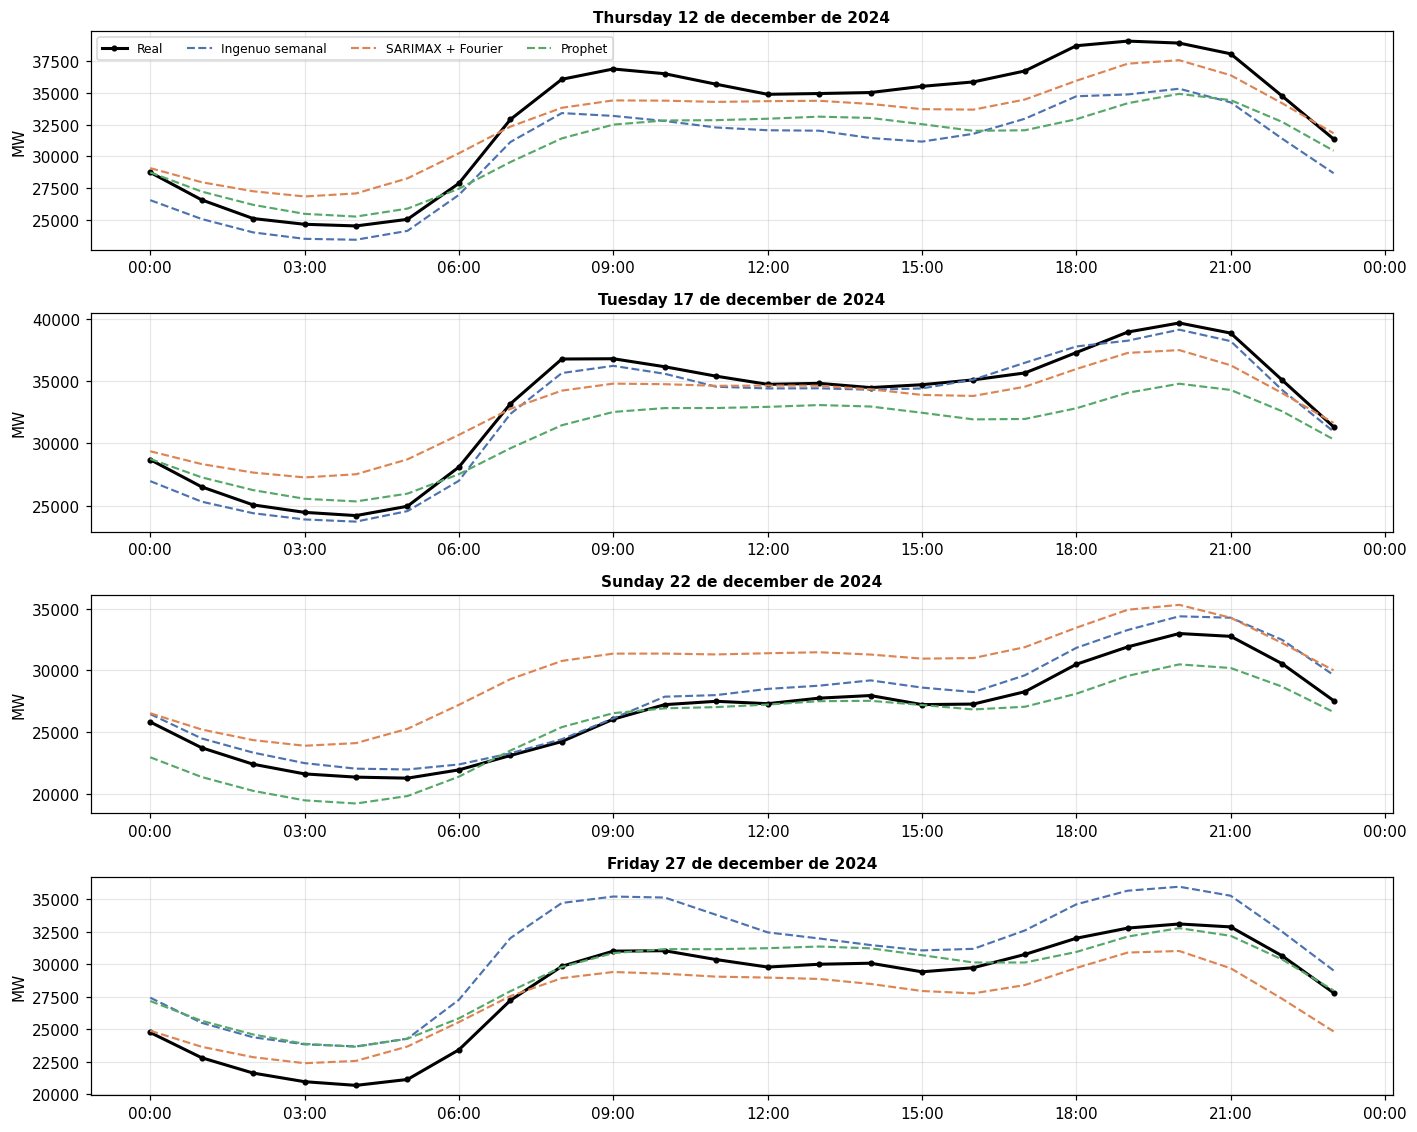

In [20]:
MEJOR = tabla.index[0]
print(f"Modelo con menor MAPE: {MEJOR}\n")

comparar = [m for m in ["Ingenuo semanal", "SARIMAX + Fourier", "Prophet"]
            if m in predicciones]

n = min(4, len(VENTANAS))
fig, axes = plt.subplots(n, 1, figsize=(13, 2.6 * n), sharex=False)
if n == 1:
    axes = [axes]

for k in range(n):
    ax = axes[k]
    idx_v = len(VENTANAS) - n + k
    base = predicciones[comparar[0]]
    tramo = base[base["ventana"] == idx_v]

    ax.plot(tramo.index, tramo["real"], color="black", lw=2,
            marker="o", ms=3, label="Real")
    for m in comparar:
        p = predicciones[m]
        p = p[p["ventana"] == idx_v]
        ax.plot(p.index, p["pred"], lw=1.4, ls="--", label=m)

    ax.set_title(f"{tramo.index[0]:%A %d de %B de %Y}".capitalize(),
                 fontweight="bold", fontsize=10)
    ax.set_ylabel("MW")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    if k == 0:
        ax.legend(fontsize=8, ncol=4)

plt.tight_layout()
guardar_figura("12_predicciones_vs_real")
plt.show()

  guardada -> 13_error_por_hora.png


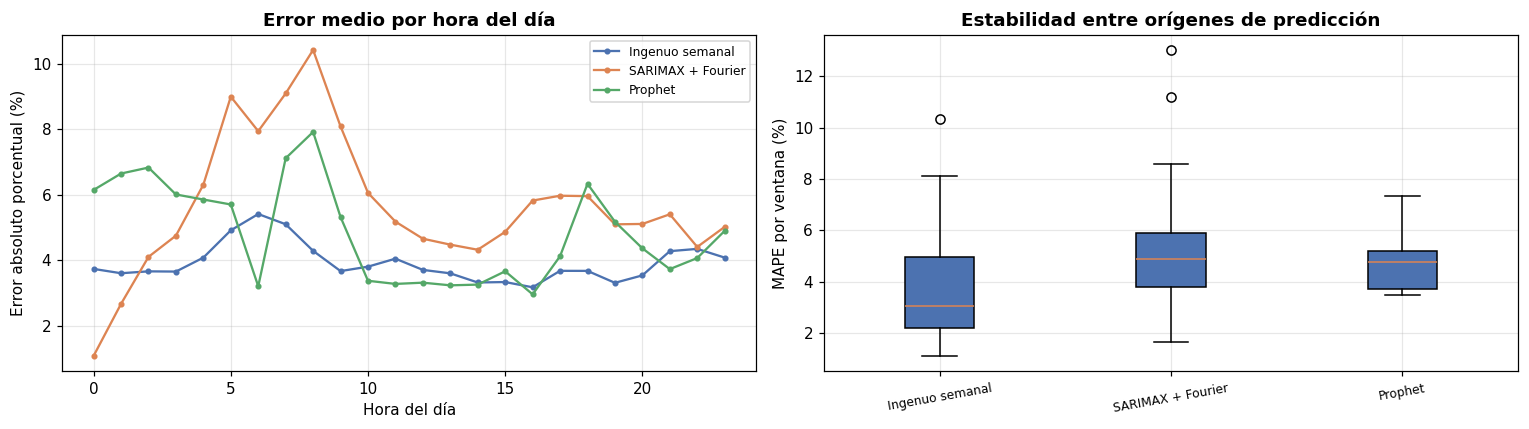

In [21]:
# ── Error por hora del día ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for m in comparar:
    p = predicciones[m].copy()
    p["hora"] = p.index.hour
    p["ape"]  = np.abs((p["real"] - p["pred"]) / p["real"]) * 100
    perfil = p.groupby("hora")["ape"].mean()
    axes[0].plot(perfil.index, perfil.values, marker="o", ms=3, lw=1.5, label=m)

axes[0].set_xlabel("Hora del día"); axes[0].set_ylabel("Error absoluto porcentual (%)")
axes[0].set_title("Error medio por hora del día", fontweight="bold")
axes[0].legend(fontsize=8)

# ── Dispersión del error entre ventanas ──────────────────────────────────
datos_box, etiquetas = [], []
for m in comparar:
    p = predicciones[m].copy()
    p["ape"] = np.abs((p["real"] - p["pred"]) / p["real"]) * 100
    datos_box.append(p.groupby("ventana")["ape"].mean().values)
    etiquetas.append(m)

axes[1].boxplot(datos_box, tick_labels=etiquetas, patch_artist=True)
axes[1].set_ylabel("MAPE por ventana (%)")
axes[1].set_title("Estabilidad entre orígenes de predicción", fontweight="bold")
axes[1].tick_params(axis="x", labelsize=8, rotation=10)

plt.tight_layout()
guardar_figura("13_error_por_hora")
plt.show()

> **Qué buscar aquí.** Si el error se dispara en las horas de rampa (entre las
> 6 y las 9, y en el pico vespertino), el modelo tiene dificultades con las
> transiciones rápidas. Es un patrón habitual y una de las cosas que los modelos
> de aprendizaje automático con desfases temporales suelen mejorar.

---
## 10. Guardado de resultados

In [22]:
todas = pd.concat(
    [p.assign(modelo=m) for m, p in predicciones.items()]
).reset_index().rename(columns={"index": "datetime"})

todas.to_parquet(DIR_RESULTADOS / "predicciones_baseline.parquet", index=False)

print(f"Predicciones guardadas: {len(todas):,} filas")
print(f"  {DIR_RESULTADOS / 'predicciones_baseline.parquet'}")
print(f"  {DIR_RESULTADOS / 'comparativa_baseline.csv'}")

print("\nResumen final\n")
print(tabla[["MAE", "RMSE", "MAPE mediana", "vs ingenuo"]].round(2).to_string())

Predicciones guardadas: 2,016 filas
  c:\Users\rober\OneDrive - unizar.es\Escritorio\Master\BigData y Ciencia de datos\TFM\GITHUB\repo_github_tfm\resultados\predicciones_baseline.parquet
  c:\Users\rober\OneDrive - unizar.es\Escritorio\Master\BigData y Ciencia de datos\TFM\GITHUB\repo_github_tfm\resultados\comparativa_baseline.csv

Resumen final

                       MAE     RMSE  MAPE mediana  vs ingenuo
Modelo                                                       
SARIMA clásico     1120.13  1640.80          2.42       20.90
Ingenuo semanal    1107.53  1472.83          3.06        0.00
Ingenuo diario     1386.74  2190.29          3.21       -5.01
Prophet            1369.57  1719.50          4.78      -56.41
SARIMAX + Fourier  1564.87  1982.84          4.90      -60.25
Perfil semanal     2433.52  2844.91          8.30     -171.23


---
## Conclusiones y siguientes pasos

### Para la memoria

Los resultados de este notebook alimentan la sección 5.2 (comparativa de
modelos). Conviene reportar:

1. **El MAPE de la mejor línea base ingenua.** Es la referencia contra la que se
   mide todo lo demás y su omisión es una debilidad frecuente en la literatura.
2. **La justificación del enfoque de Fourier**, respaldada por la comparación de
   tiempos de la sección 5.4.
3. **La diferencia entre error de entrenamiento y de producción**, con el matiz
   sobre el horizonte de predicción.
4. **El error por hora del día**, que anticipa dónde pueden mejorar los modelos
   de aprendizaje automático.

### Notebook 03

Modelos de aprendizaje automático sobre las variables construidas en el
notebook 01: Random Forest, XGBoost y LightGBM, con optimización de
hiperparámetros y análisis de importancia mediante SHAP.

La comparación será directa: mismo esquema de origen rodante, mismas ventanas y
mismas métricas.